# 02 — Disaggregator

Perfect (dummy) disaggregator vs the scenario's ground-truth per-appliance power over a test-window slice.

The default `Disaggregator` intentionally returns simulator ground truth (perfect score) so the project can focus on the closed-loop agent (triggers + MPC + HITL), not real-world NILM accuracy.

This notebook also includes basic assertions to verify the perfect disaggregator contract (`active`/power consistency against ground truth).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from datetime import timedelta

import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

from aerogrid.config import SCENARIO_DIR, SCENARIO_TEST_START
from aerogrid.nilm import Disaggregator, PerfectDisaggModel
from aerogrid.sim.scenario import load_scenario_mains, load_scenario_appliance

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

disagg = Disaggregator.from_scenario(
    scenario_dir=SCENARIO_DIR,
    appliances=['dishwasher', 'ev_charger', 'fridge', 'heater', 'washing_machine'],
    split='test',
)
print('loaded appliances:', disagg.appliances())

loaded appliances: ['dishwasher', 'ev_charger', 'fridge', 'heater', 'washing_machine']


In [2]:
# Grab a 50-hour slice starting 19 h into the test window.
mains = load_scenario_mains()
start = SCENARIO_TEST_START + timedelta(hours=19)   # overlaps the natural dishwasher / EV times
end   = start + timedelta(hours=50)

slice_df = mains[(mains['timestamp'] >= start) & (mains['timestamp'] < end)].reset_index(drop=True)
print(f'{len(slice_df)} samples  |  {slice_df["timestamp"].iloc[0]}  →  {slice_df["timestamp"].iloc[-1]}')

# Alignment is by timestamp join — no start_idx needed.
estimates = disagg.disaggregate(slice_df)
print('estimates index:', estimates.index[0], '→', estimates.index[-1])
print('appliances:', list(estimates.columns))

180000 samples  |  2026-04-03 19:00:00+00:00  →  2026-04-05 20:59:59+00:00
estimates index: 2026-04-03 19:00:00+00:00 → 2026-04-05 20:59:59+00:00
appliances: ['dishwasher', 'ev_charger', 'fridge', 'heater', 'washing_machine']


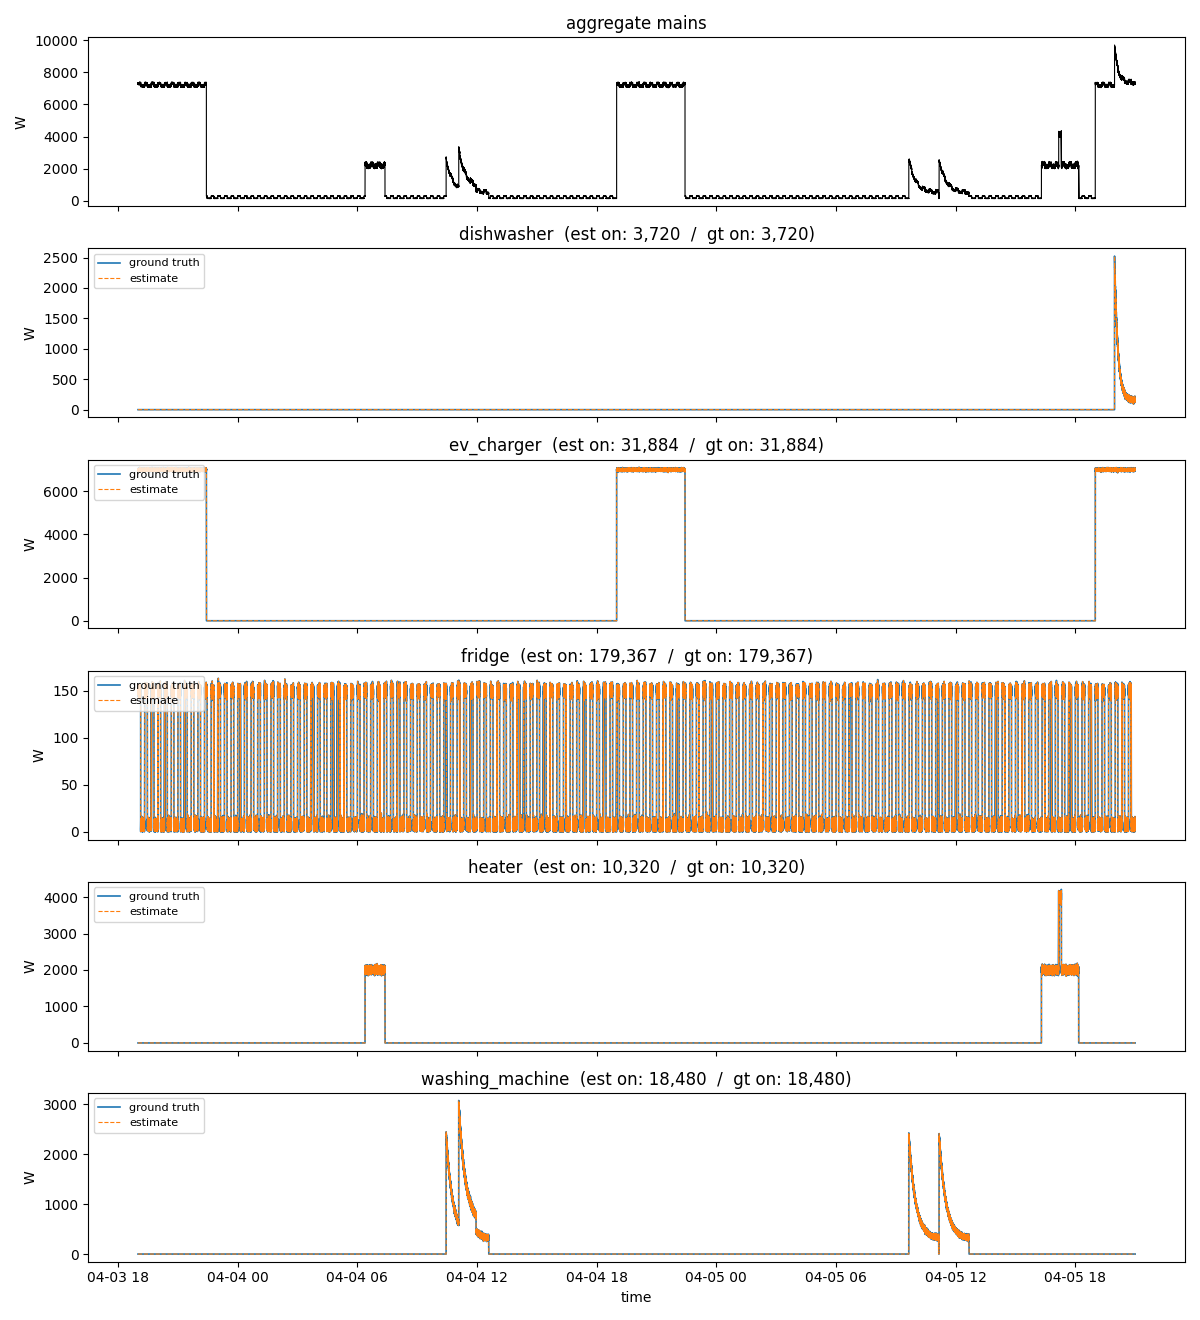

In [3]:
# Plot mains + per-appliance panels.
# Ground truth (blue) and disaggregator estimate (orange dashed) should overlap perfectly.
n_rows = 1 + len(estimates.columns)
fig, axes = plt.subplots(n_rows, 1, figsize=(12, 2.2 * n_rows), sharex=True)

axes[0].plot(slice_df['timestamp'], slice_df['power_w'], lw=0.8, color='black')
axes[0].set_ylabel('W')
axes[0].set_title('aggregate mains')

for i, name in enumerate(estimates.columns):
    est = estimates[name]                          # Series with DatetimeIndex
    gt = load_scenario_appliance(name)
    gt = gt[(gt['timestamp'] >= start) & (gt['timestamp'] < end)].reset_index(drop=True)
    gt_arr = gt['power_w'].to_numpy(np.float32)

    ax = axes[1 + i]
    ax.plot(slice_df['timestamp'], gt_arr, lw=1.2, color='C0', label='ground truth')
    ax.plot(estimates.index, est.to_numpy(), lw=0.8, color='C1', linestyle='--', label='estimate')
    ax.set_ylabel('W')
    ax.set_title(
        f'{name}  (est on: {int((est > 0).sum()):,}  /  gt on: {int((gt_arr > 0).sum()):,})'
    )
    ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

In [4]:
# Notebook-level checks for the timestamp-aware perfect disaggregator contract.
for name in estimates.columns:
    est_arr = estimates[name].to_numpy(np.float32)

    gt = load_scenario_appliance(name)
    gt = gt[(gt['timestamp'] >= start) & (gt['timestamp'] < end)].reset_index(drop=True)
    gt_arr = gt['power_w'].to_numpy(np.float32)

    # Disaggregator must match ground truth exactly (alignment by timestamp join).
    np.testing.assert_allclose(est_arr, gt_arr, atol=0.0,
                               err_msg=f'{name}: estimate does not match ground truth')

    # Active (0/1) flags must be consistent with power level.
    model = PerfectDisaggModel(gt_arr, threshold_w=1.0)
    active = np.array([model.at(i)[0] for i in range(len(gt_arr))], dtype=np.float32)
    np.testing.assert_array_equal(active, (gt_arr > 1.0).astype(np.float32))

print('Notebook checks passed: timestamp-aligned estimates match ground truth exactly.')

Notebook checks passed: timestamp-aligned estimates match ground truth exactly.
